<a href="https://colab.research.google.com/github/Garfieldslard/Crime-Analysis/blob/main/models/DATA_205_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 205 — Predictive Modeling
**Target:** `response_time_min` (raw) and `log(response_time_min)`  
**Models:** OLS Regression, Random Forest  
**Dataset:** `dispatch_rt.csv` (n≈192k, dispatched calls with recorded arrival, RT 1–120 min)  
**Goal:** Identify what predicts dispatch response time and compare model performance

## 0. Imports & Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels for OLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sklearn for Random Forest + evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42

# Load data
disp_rt = pd.read_csv('dispatch_rt.csv')
print(f'Loaded dispatch_rt: {len(disp_rt):,} rows')
print(f'Columns: {disp_rt.columns.tolist()}')

Loaded dispatch_rt: 178,030 rows
Columns: ['incident_id', 'start time', 'end time', 'priority', 'initial type', 'close type', 'address', 'city', 'state', 'zip', 'longitude', 'latitude', 'police district number', 'beat', 'pra', 'calltime callroute', 'calltime dispatch', 'calltime arrive', 'calltime cleared', 'callroute dispatch', 'dispatch arrive', 'arrive cleared', 'disposition desc', 'location', 'start_dt', 'end_dt', 'hour', 'day_of_week', 'dow_name', 'month', 'month_name', 'is_weekend', 'time_of_day', 'response_time_s', 'response_time_min', 'response_time_cap', 'total_incident_s', 'total_incident_min', 'queue_time_s', 'onscene_time_s', 'rt_outlier', 'type_changed', 'priority_label', 'incident_category', 'district_crime_count', 'pra_float', 'pra_crime', 'pra_crime_count', 'no_arrival', 'never_dispatched']


---
## 1. Feature Preparation

Select candidate predictors identified in the statistical tests phase. Encode categoricals and create the log target.

In [32]:
# ── Target variables ─────────────────────────────────────────────────
disp_rt['log_response_time'] = np.log(disp_rt['response_time_min'])

# ── Cyclic encoding for hour (captures 23→0 continuity) ──────────────
disp_rt['hour_sin'] = np.sin(2 * np.pi * disp_rt['hour'] / 24)
disp_rt['hour_cos'] = np.cos(2 * np.pi * disp_rt['hour'] / 24)

# ── Select features ───────────────────────────────────────────────────
# Confirmed available from statistical tests phase
CATEGORICAL = ['incident_category', 'priority_label', 'time_of_day', 'police district number']
NUMERIC     = ['hour_sin', 'hour_cos', 'is_weekend', 'type_changed']

# For OLS only — remove district from categoricals
CATEGORICAL_OLS = ['incident_category', 'priority_label', 'time_of_day']
CATEGORICAL_RF  = ['incident_category', 'priority_label', 'time_of_day', 'police district number']

# Add district_crime_count if available
if 'district_crime_count' in disp_rt.columns:
    NUMERIC.append('district_crime_count')

# Check all features exist
all_features = CATEGORICAL + NUMERIC
missing = [c for c in all_features if c not in disp_rt.columns]
if missing:
    print(f'WARNING — missing columns: {missing}')
    CATEGORICAL = [c for c in CATEGORICAL if c in disp_rt.columns]
    NUMERIC     = [c for c in NUMERIC     if c in disp_rt.columns]
    all_features = CATEGORICAL + NUMERIC

print(f'Categorical features: {CATEGORICAL}')
print(f'Numeric features:     {NUMERIC}')

# ── Drop rows with any NA in features or target ───────────────────────
model_df = disp_rt[all_features + ['response_time_min','log_response_time']].dropna()
print(f'\nModeling dataset: {len(model_df):,} rows after dropping NAs')

Categorical features: ['incident_category', 'priority_label', 'time_of_day', 'police district number']
Numeric features:     ['hour_sin', 'hour_cos', 'is_weekend', 'type_changed', 'district_crime_count']

Modeling dataset: 178,027 rows after dropping NAs


In [33]:
# OLS feature matrix (no district)
model_ols = pd.get_dummies(model_df, columns=CATEGORICAL_OLS, drop_first=True)
feature_cols_rf_ols = [c for c in model_ols.columns
                    if c not in ['response_time_min', 'log_response_time', 'police district number']]
X_ols = model_ols[feature_cols_rf_ols].astype(float)

# RF feature matrix (with district)
model_rf = pd.get_dummies(model_df, columns=CATEGORICAL_RF, drop_first=True)
feature_cols_rf_rf = [c for c in model_rf.columns
                   if c not in ['response_time_min', 'log_response_time']]
X_rf = model_rf[feature_cols_rf_rf].astype(float)

In [34]:
# ── One-hot encode categoricals (for OLS + RF) ────────────────────────
model_encoded = pd.get_dummies(model_df, columns=CATEGORICAL, drop_first=True)

# Feature columns after encoding
feature_cols_rf = [c for c in model_encoded.columns
                if c not in ['response_time_min','log_response_time']]

X = model_encoded[feature_cols_rf].astype(float)
y_raw = model_encoded['response_time_min']
y_log = model_encoded['log_response_time']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_cols_rf}')

Feature matrix shape: (178027, 26)
Features: ['hour_sin', 'hour_cos', 'is_weekend', 'type_changed', 'district_crime_count', 'incident_category_Domestic', 'incident_category_Other', 'incident_category_Parking', 'incident_category_Suspicious', 'incident_category_Theft/Burglary', 'incident_category_Traffic', 'incident_category_Trespassing', 'incident_category_Violent', 'incident_category_Welfare/Mental', 'priority_label_P1-High', 'priority_label_P2-Medium', 'priority_label_P3-Low', 'priority_label_P4-Standard', 'time_of_day_Evening (18–23)', 'time_of_day_Late Night (0–5)', 'time_of_day_Morning (6–11)', 'police district number_2D', 'police district number_3D', 'police district number_4D', 'police district number_5D', 'police district number_6D']


---
## 2. Train / Test Split

In [35]:
# OLS split
X_ols_train, X_ols_test, y_raw_train, y_raw_test, y_log_train, y_log_test = train_test_split(
    X_ols, y_raw, y_log, test_size=0.2, random_state=SEED
)

# RF split
X_rf_train, X_rf_test, _, _, _, _ = train_test_split(
    X_rf, y_raw, y_log, test_size=0.2, random_state=SEED
)

print(f'OLS Train: {len(X_ols_train):,} | OLS Test: {len(X_ols_test):,}')
print(f'RF Train:  {len(X_rf_train):,} | RF Test:  {len(X_rf_test):,}')


OLS Train: 142,421 | OLS Test: 35,606
RF Train:  142,421 | RF Test:  35,606


---
## 3. OLS Regression

### 3.1 OLS on Raw Response Time

In [38]:
X_ols_train_const = sm.add_constant(X_ols_train)
X_ols_test_const  = sm.add_constant(X_ols_test)

ols_raw = sm.OLS(y_raw_train, X_ols_train_const).fit()
print(ols_raw.summary())

                            OLS Regression Results                            
Dep. Variable:      response_time_min   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     606.8
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:04:15   Log-Likelihood:            -5.5414e+05
No. Observations:              142421   AIC:                         1.108e+06
Df Residuals:                  142399   BIC:                         1.109e+06
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [42]:
# Test set performance
y_raw_pred_ols = ols_raw.predict(X_ols_test_const)

r2_ols_raw  = r2_score(y_raw_test, y_raw_pred_ols)
mae_ols_raw = mean_absolute_error(y_raw_test, y_raw_pred_ols)
rmse_ols_raw= np.sqrt(mean_squared_error(y_raw_test, y_raw_pred_ols))

print('OLS (raw target) — Test Set Performance')
print(f'  R²   : {r2_ols_raw:.4f}')
print(f'  MAE  : {mae_ols_raw:.3f} min')
print(f'  RMSE : {rmse_ols_raw:.3f} min')

OLS (raw target) — Test Set Performance
  R²   : 0.0765
  MAE  : 7.400 min
  RMSE : 11.789 min


### 3.2 OLS on Log Response Time

In [39]:
ols_log = sm.OLS(y_log_train, X_ols_train_const).fit()
print(ols_log.summary())

                            OLS Regression Results                            
Dep. Variable:      log_response_time   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     896.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:04:28   Log-Likelihood:            -1.6873e+05
No. Observations:              142421   AIC:                         3.375e+05
Df Residuals:                  142399   BIC:                         3.377e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [44]:
# Test set performance — back-transform predictions for interpretable metrics
y_log_pred_ols = ols_log.predict(X_ols_test_const)
y_log_pred_ols_bt    = np.exp(y_log_pred_ols)   # back-transformed to minutes

r2_ols_log   = r2_score(y_log_test, y_log_pred_ols)
mae_ols_log  = mean_absolute_error(y_raw_test, y_log_pred_ols_bt)
rmse_ols_log = np.sqrt(mean_squared_error(y_raw_test, y_log_pred_ols_bt))

print('OLS (log target) — Test Set Performance')
print(f'  R² (on log scale)       : {r2_ols_log:.4f}')
print(f'  MAE (back-transformed)  : {mae_ols_log:.3f} min')
print(f'  RMSE (back-transformed) : {rmse_ols_log:.3f} min')

OLS (log target) — Test Set Performance
  R² (on log scale)       : 0.1113
  MAE (back-transformed)  : 6.840 min
  RMSE (back-transformed) : 12.287 min


### 3.3 OLS Residual Diagnostics

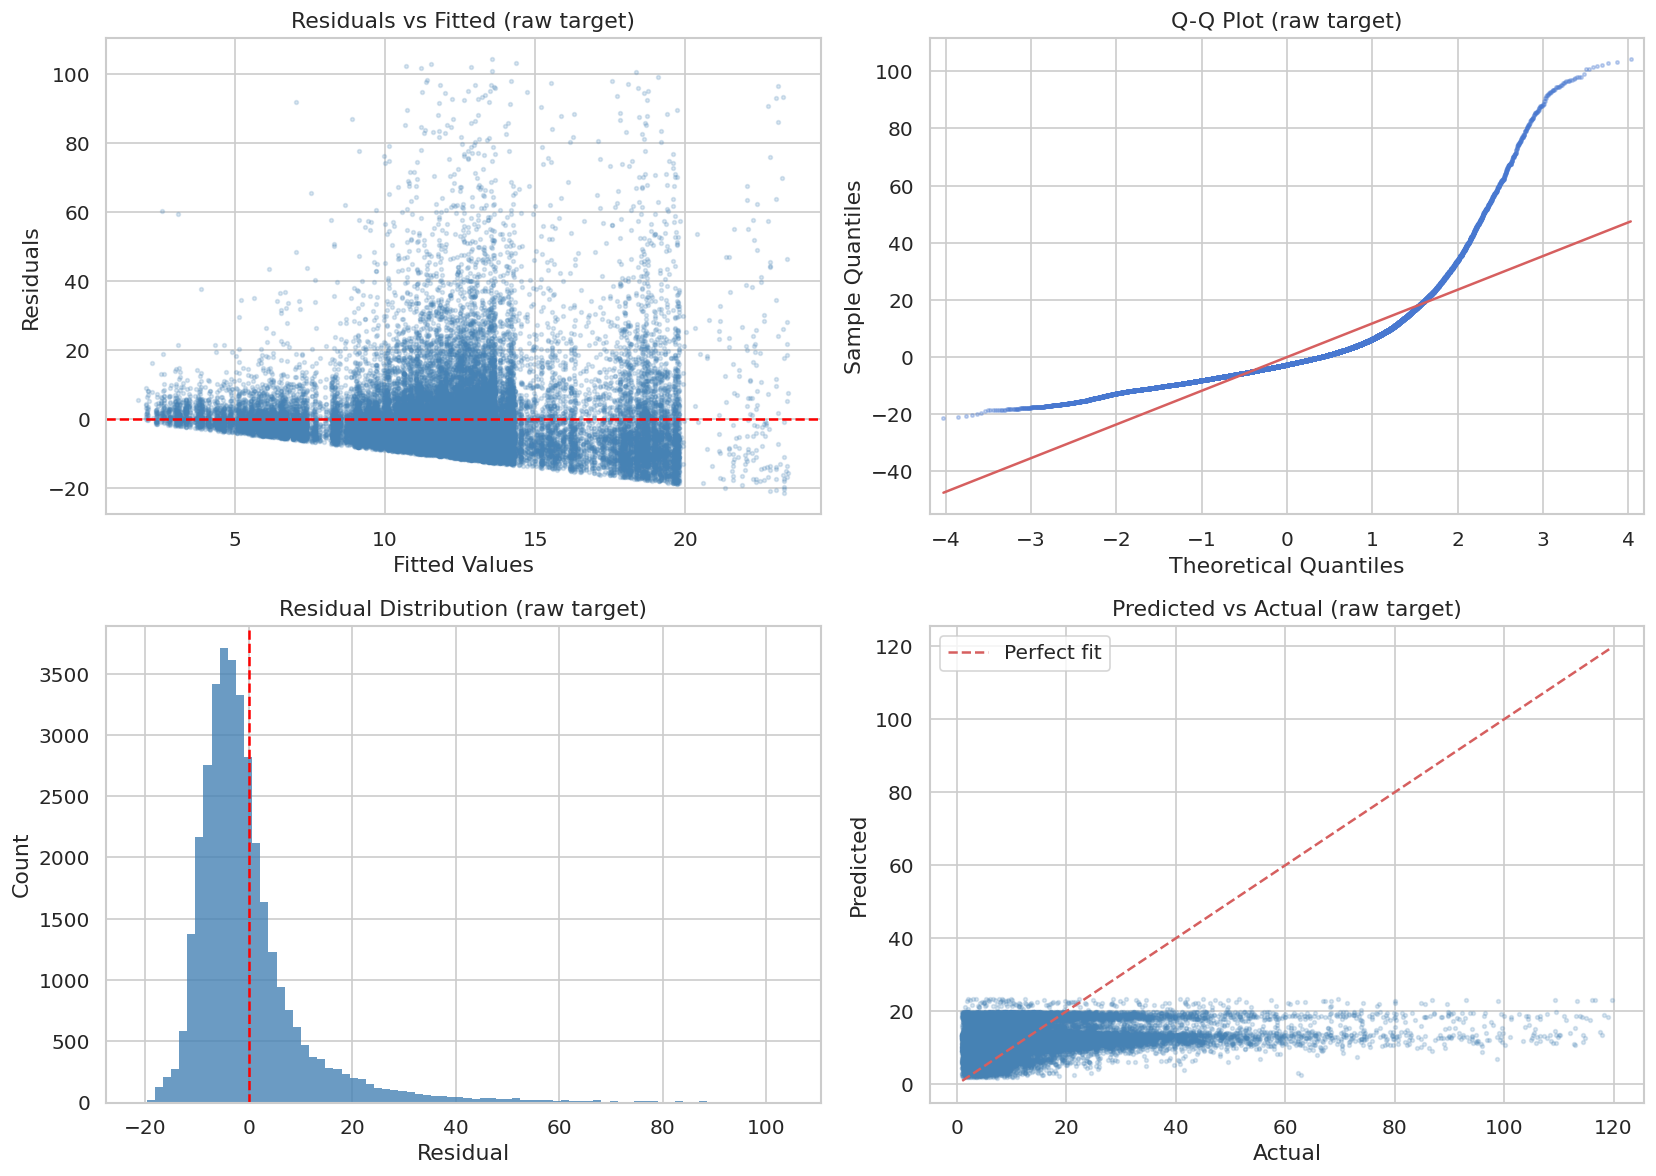

In [45]:
def plot_ols_diagnostics(model, X_rf_test, y_test, y_pred, title_suffix=''):
    residuals    = y_test - y_pred
    standardized = (residuals - residuals.mean()) / residuals.std()

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig)

    # 1. Residuals vs Fitted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_pred, residuals, alpha=0.2, s=5, color='steelblue')
    ax1.axhline(0, color='red', linestyle='--')
    ax1.set_xlabel('Fitted Values')
    ax1.set_ylabel('Residuals')
    ax1.set_title(f'Residuals vs Fitted {title_suffix}')

    # 2. Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    sm.qqplot(residuals, line='s', ax=ax2, alpha=0.3, markersize=2)
    ax2.set_title(f'Q-Q Plot {title_suffix}')

    # 3. Histogram of residuals
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(residuals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax3.axvline(0, color='red', linestyle='--')
    ax3.set_xlabel('Residual')
    ax3.set_ylabel('Count')
    ax3.set_title(f'Residual Distribution {title_suffix}')

    # 4. Predicted vs Actual
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax4.plot(lims, lims, 'r--', label='Perfect fit')
    ax4.set_xlabel('Actual')
    ax4.set_ylabel('Predicted')
    ax4.set_title(f'Predicted vs Actual {title_suffix}')
    ax4.legend()

    plt.tight_layout()
    plt.savefig(f'fig_ols_diagnostics{title_suffix.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

# Raw target
plot_ols_diagnostics(ols_raw, X_ols_test, y_raw_test, y_raw_pred_ols, '(raw target)')

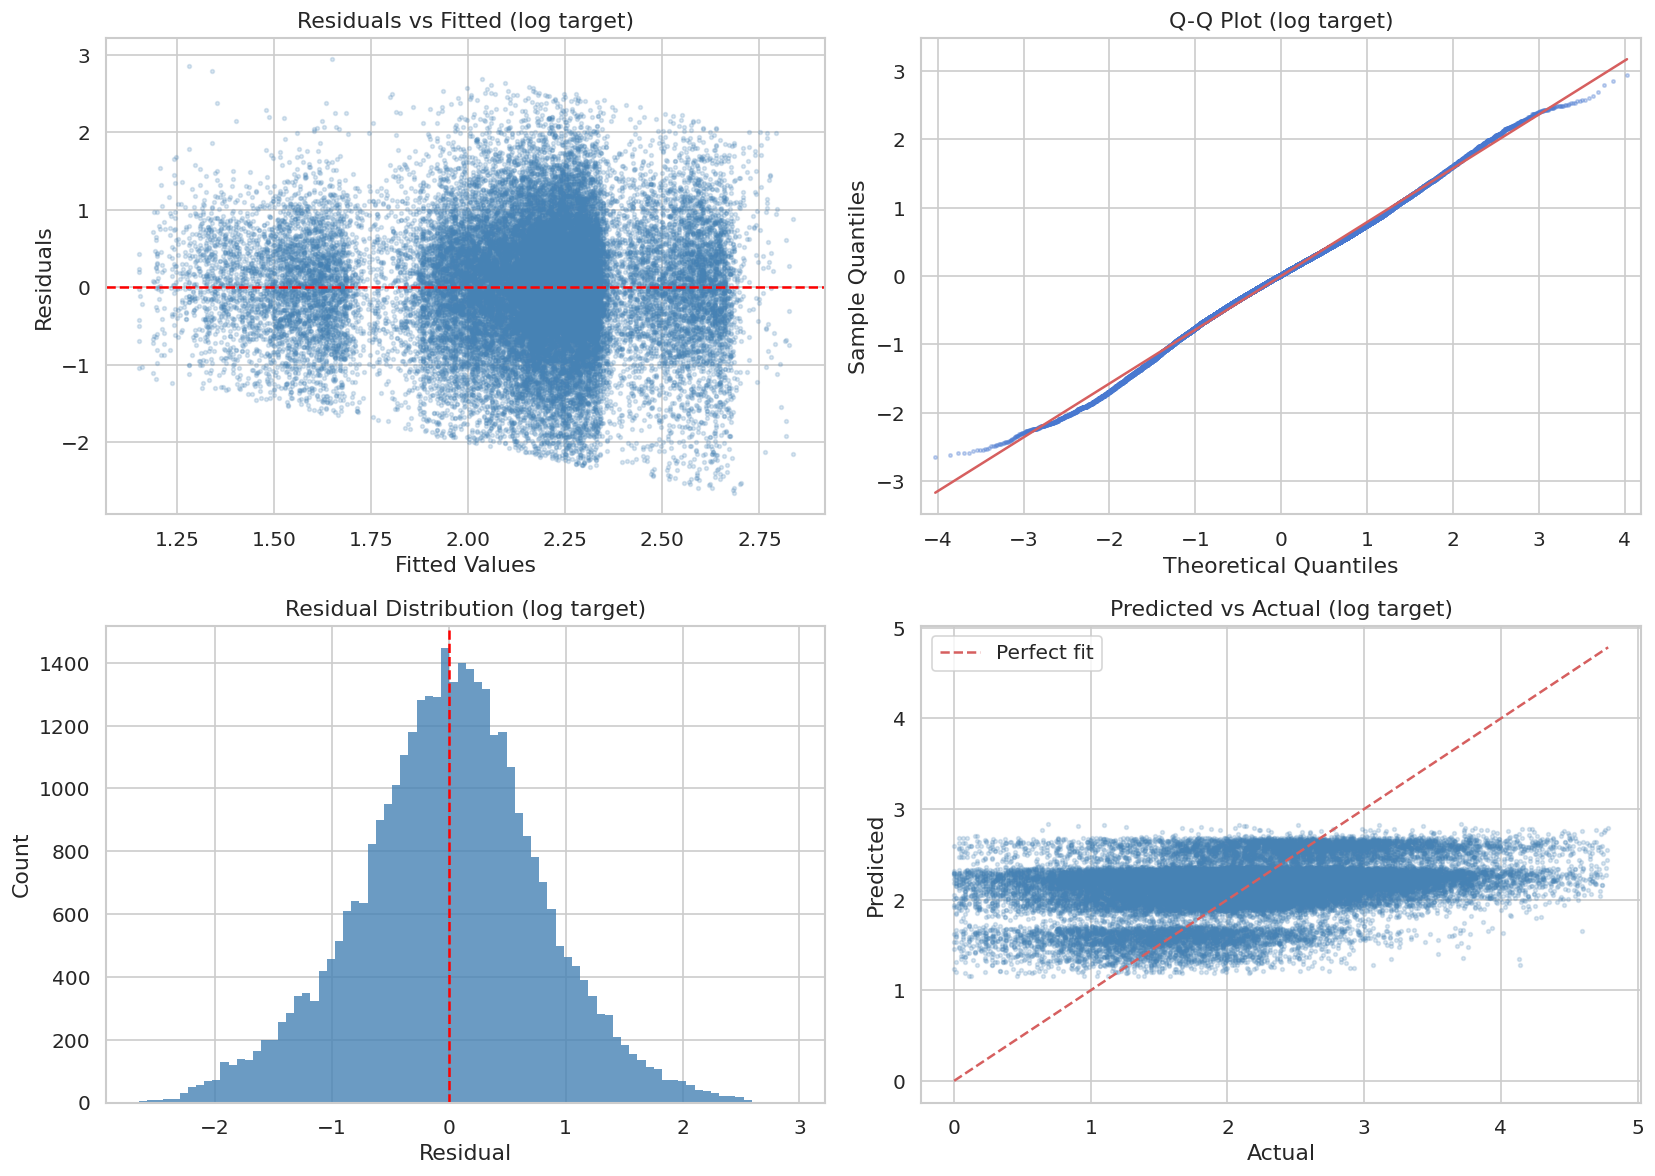

In [46]:
# Log target
plot_ols_diagnostics(ols_log, X_ols_test, y_log_test, y_log_pred_ols, '(log target)')

### 3.4 Variance Inflation Factor (Multicollinearity Check)

In [47]:
X_vif = sm.add_constant(X_ols_train)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)

print('Variance Inflation Factors (VIF > 10 indicates multicollinearity):')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\nWARNING: {len(high_vif)} features with VIF > 10:')
    print(high_vif.to_string(index=False))
else:
    print('\nNo multicollinearity concerns (all VIF < 10).')

Variance Inflation Factors (VIF > 10 indicates multicollinearity):
                         Feature      VIF
                        hour_cos 5.615330
    time_of_day_Late Night (0–5) 5.077006
                        hour_sin 5.013241
     time_of_day_Evening (18–23) 4.901418
         incident_category_Other 4.473597
      time_of_day_Morning (6–11) 4.271987
       incident_category_Traffic 3.505990
incident_category_Theft/Burglary 3.318093
          priority_label_P1-High 3.203051
        priority_label_P2-Medium 2.947783
incident_category_Welfare/Mental 2.656299
    incident_category_Suspicious 2.444304
      incident_category_Domestic 2.315183
      priority_label_P4-Standard 2.260983
   incident_category_Trespassing 2.022182
       incident_category_Violent 1.758889
       incident_category_Parking 1.689870
           priority_label_P3-Low 1.522932
                    type_changed 1.017542
                      is_weekend 1.012798
            district_crime_count 1.006124

No multi

### 3.5 OLS Coefficient Plot

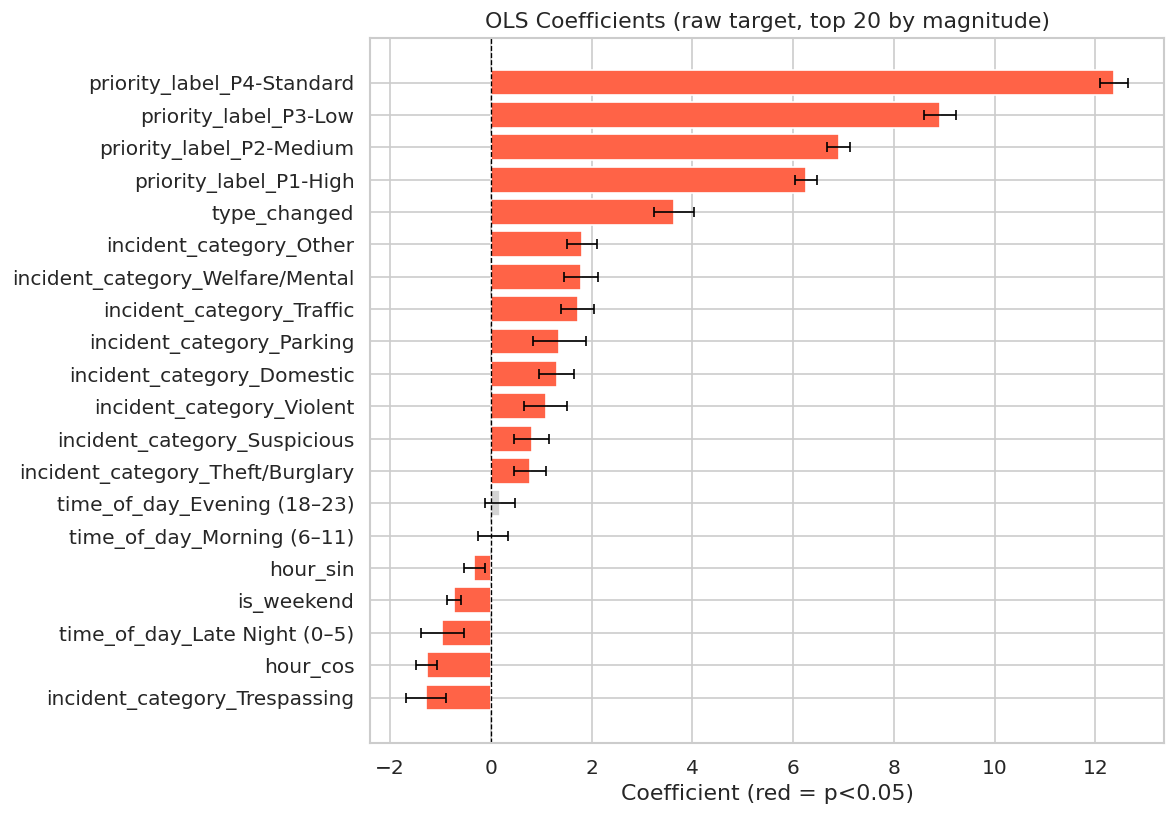

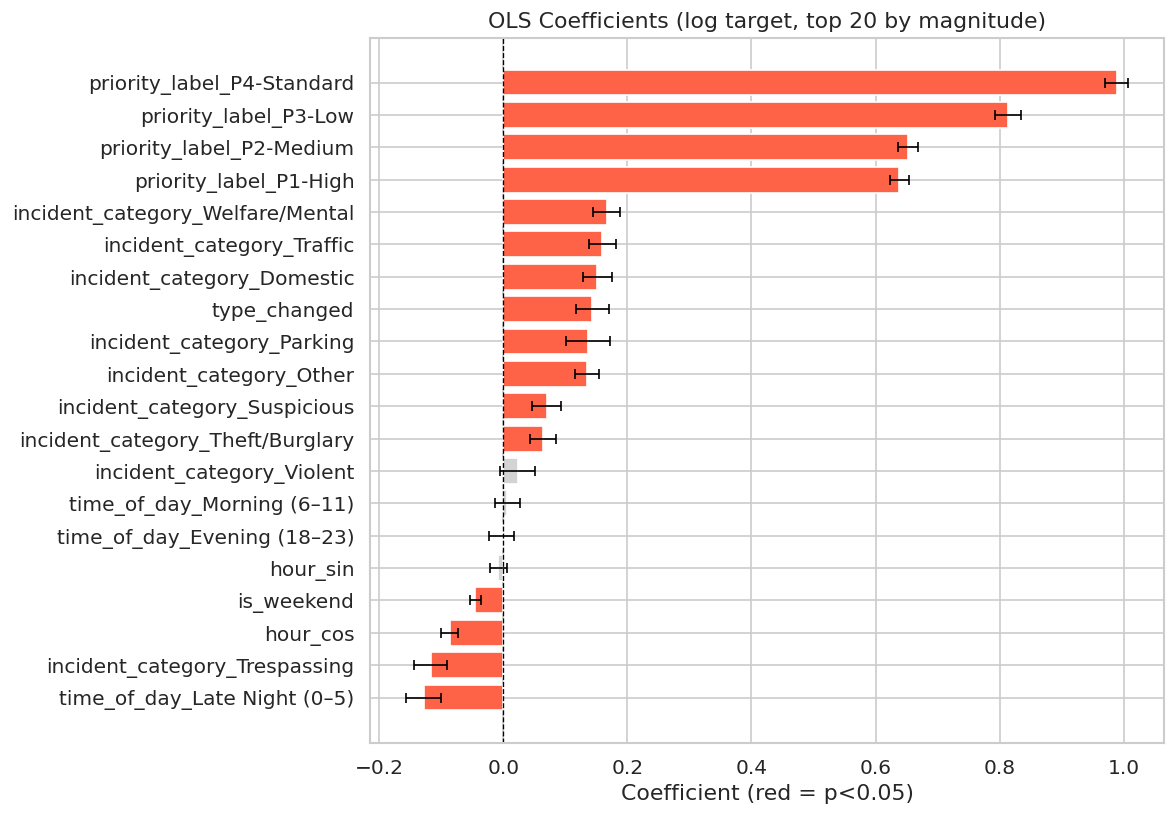

In [48]:
def plot_ols_coefs(model, title, n=20):
    coefs = pd.DataFrame({
        'Feature'  : model.params.index,
        'Coef'     : model.params.values,
        'CI_lower' : model.conf_int()[0].values,
        'CI_upper' : model.conf_int()[1].values,
        'p_value'  : model.pvalues.values
    })
    coefs = coefs[coefs['Feature'] != 'const']
    coefs['abs_coef'] = coefs['Coef'].abs()
    coefs = coefs.nlargest(n, 'abs_coef').sort_values('Coef')

    colors = ['tomato' if p < 0.05 else 'lightgray' for p in coefs['p_value']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(coefs)*0.35)))
    ax.barh(coefs['Feature'], coefs['Coef'], color=colors, edgecolor='white')
    ax.errorbar(
        coefs['Coef'], coefs['Feature'],
        xerr=[coefs['Coef']-coefs['CI_lower'], coefs['CI_upper']-coefs['Coef']],
        fmt='none', color='black', capsize=3, linewidth=1
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Coefficient (red = p<0.05)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'fig_ols_coefs_{title[:10].replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

plot_ols_coefs(ols_raw, f'OLS Coefficients (raw target, top 20 by magnitude)')
plot_ols_coefs(ols_log, f'OLS Coefficients (log target, top 20 by magnitude)')

---
## 4. Random Forest

### 4.1 Train on Raw Target

In [51]:
rf_raw = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)
rf_raw.fit(X_rf_train, y_raw_train)
y_raw_pred_rf = rf_raw.predict(X_rf_test)

r2_rf_raw   = r2_score(y_raw_test, y_raw_pred_rf)
mae_rf_raw  = mean_absolute_error(y_raw_test, y_raw_pred_rf)
rmse_rf_raw = np.sqrt(mean_squared_error(y_raw_test, y_raw_pred_rf))

print('Random Forest (raw target) — Test Set Performance')
print(f'  R²   : {r2_rf_raw:.4f}')
print(f'  MAE  : {mae_rf_raw:.3f} min')
print(f'  RMSE : {rmse_rf_raw:.3f} min')

Random Forest (raw target) — Test Set Performance
  R²   : 0.0919
  MAE  : 7.301 min
  RMSE : 11.690 min


### 4.2 Train on Log Target

In [52]:
rf_log = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)
rf_log.fit(X_rf_train, y_log_train)
y_log_pred_rf = rf_log.predict(X_rf_test)
y_log_pred_rf_bt = np.exp(y_log_pred_rf)   # back-transform

r2_rf_log   = r2_score(y_log_test, y_log_pred_rf)
mae_rf_log  = mean_absolute_error(y_raw_test, y_log_pred_rf_bt)
rmse_rf_log = np.sqrt(mean_squared_error(y_raw_test, y_log_pred_rf_bt))

print('Random Forest (log target) — Test Set Performance')
print(f'  R² (on log scale)       : {r2_rf_log:.4f}')
print(f'  MAE (back-transformed)  : {mae_rf_log:.3f} min')
print(f'  RMSE (back-transformed) : {rmse_rf_log:.3f} min')

Random Forest (log target) — Test Set Performance
  R² (on log scale)       : 0.1239
  MAE (back-transformed)  : 6.796 min
  RMSE (back-transformed) : 12.264 min


### 4.3 Random Forest Residual Diagnostics

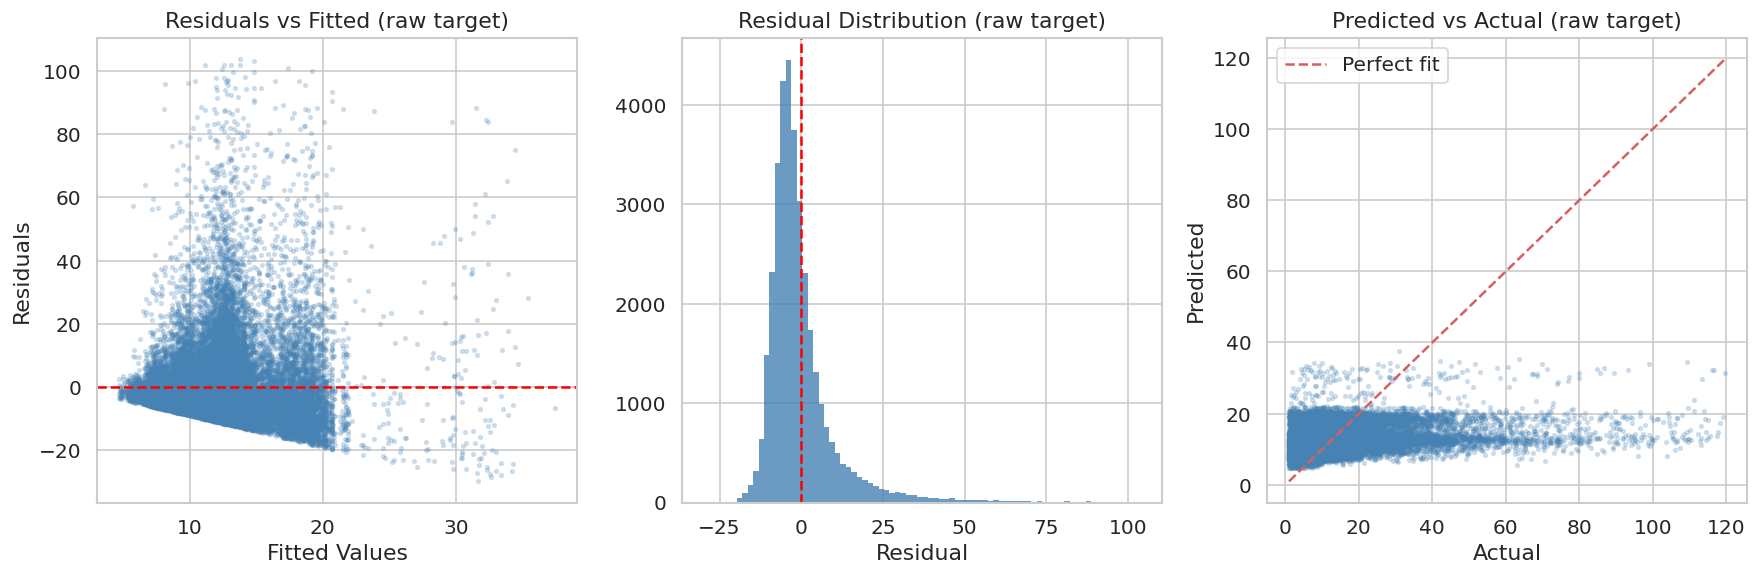

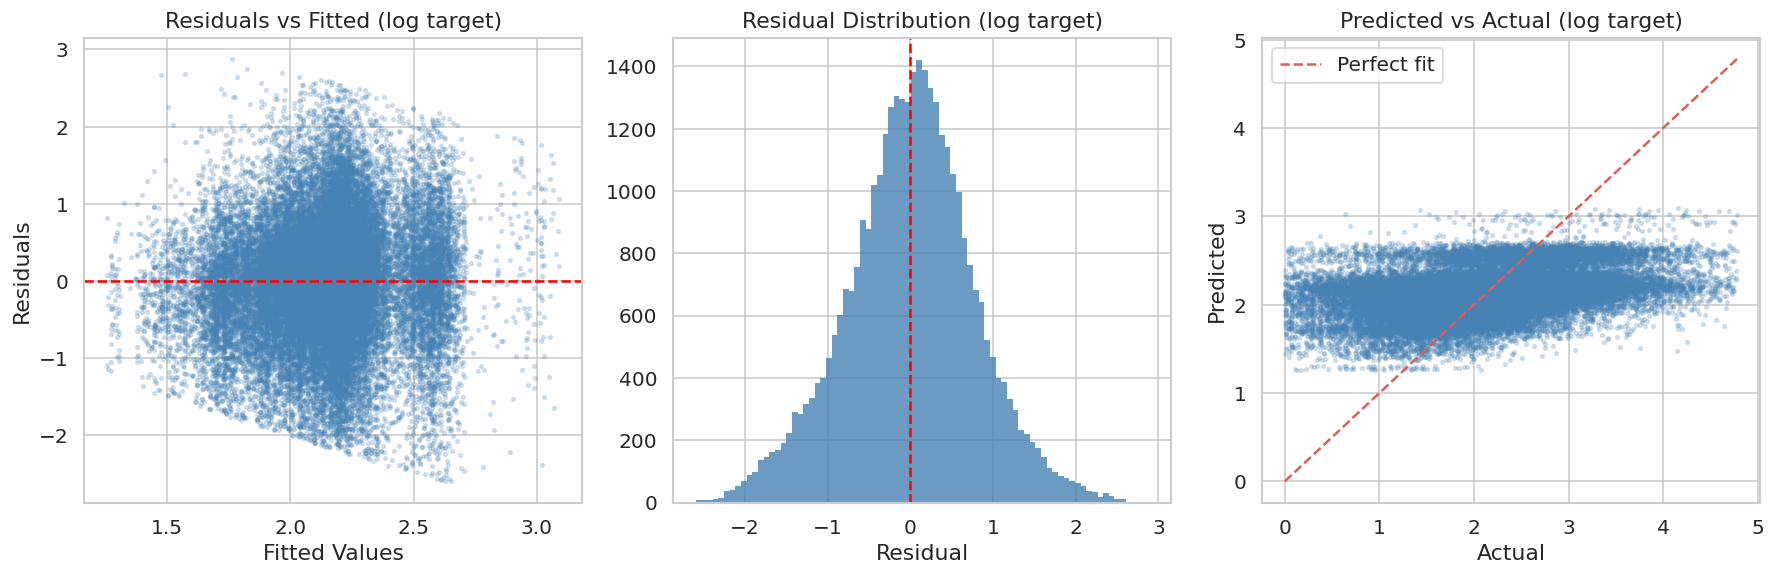

In [53]:
def plot_rf_diagnostics(y_test, y_pred, title_suffix=''):
    residuals = y_test.values - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Residuals vs Fitted
    axes[0].scatter(y_pred, residuals, alpha=0.2, s=5, color='steelblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title(f'Residuals vs Fitted {title_suffix}')

    # Residual distribution
    axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_xlabel('Residual')
    axes[1].set_title(f'Residual Distribution {title_suffix}')

    # Predicted vs Actual
    axes[2].scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[2].plot(lims, lims, 'r--', label='Perfect fit')
    axes[2].set_xlabel('Actual')
    axes[2].set_ylabel('Predicted')
    axes[2].set_title(f'Predicted vs Actual {title_suffix}')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f'fig_rf_diagnostics{title_suffix.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

plot_rf_diagnostics(y_raw_test, y_raw_pred_rf, '(raw target)')
plot_rf_diagnostics(y_log_test, y_log_pred_rf, '(log target)')

### 4.4 Feature Importance

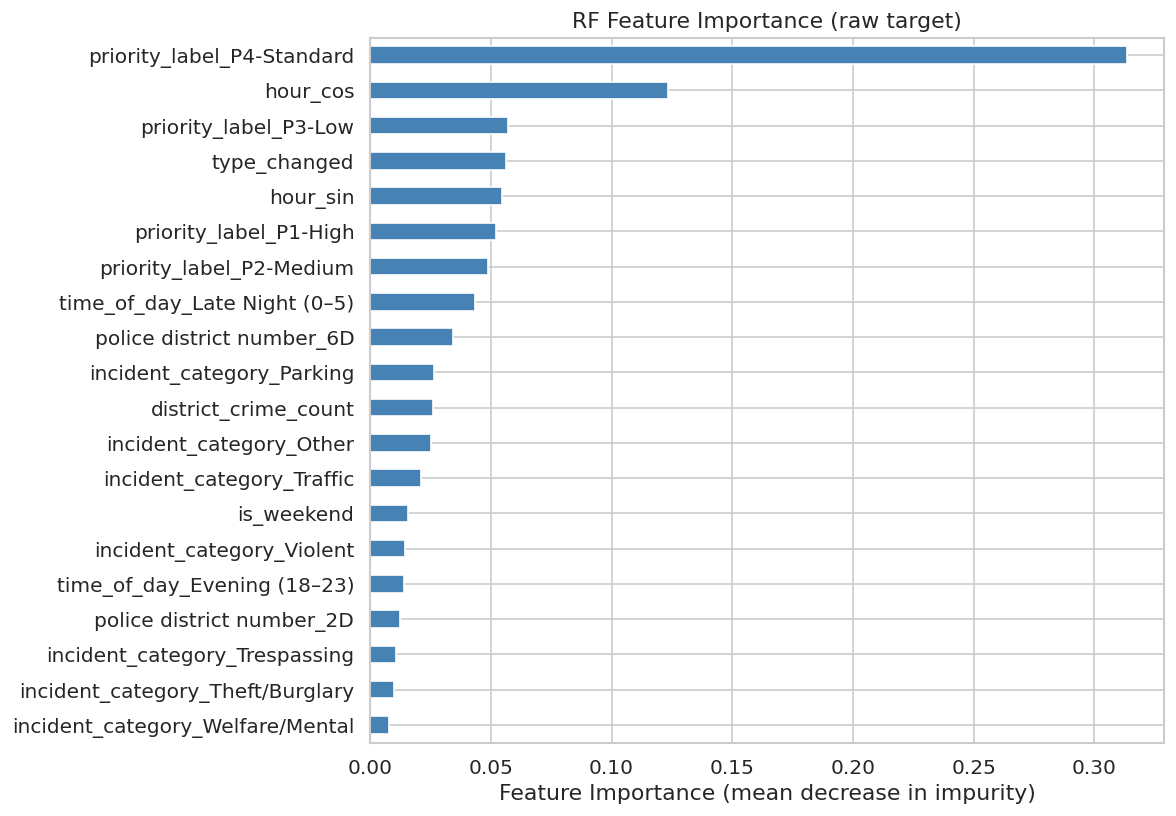

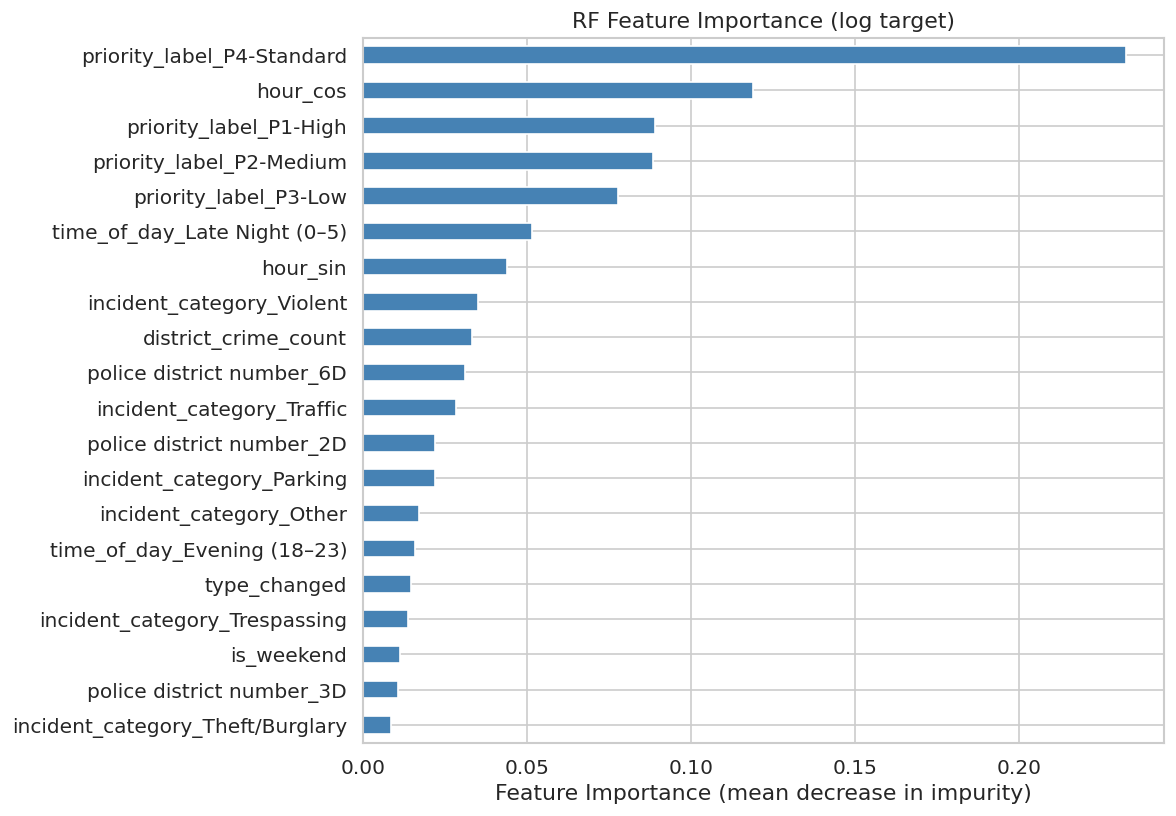

In [54]:
def plot_feature_importance(model, feature_names, title, top_n=20):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Feature Importance (mean decrease in impurity)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'fig_rf_importance_{title[:15].replace(" ","_")}.png', bbox_inches='tight')
    plt.show()
    return importances

imp_raw = plot_feature_importance(rf_raw, feature_cols_rf,
                                   'RF Feature Importance (raw target)', top_n=20)
imp_log = plot_feature_importance(rf_log, feature_cols_rf,
                                   'RF Feature Importance (log target)', top_n=20)

Computing permutation importance (this may take ~1 min)...


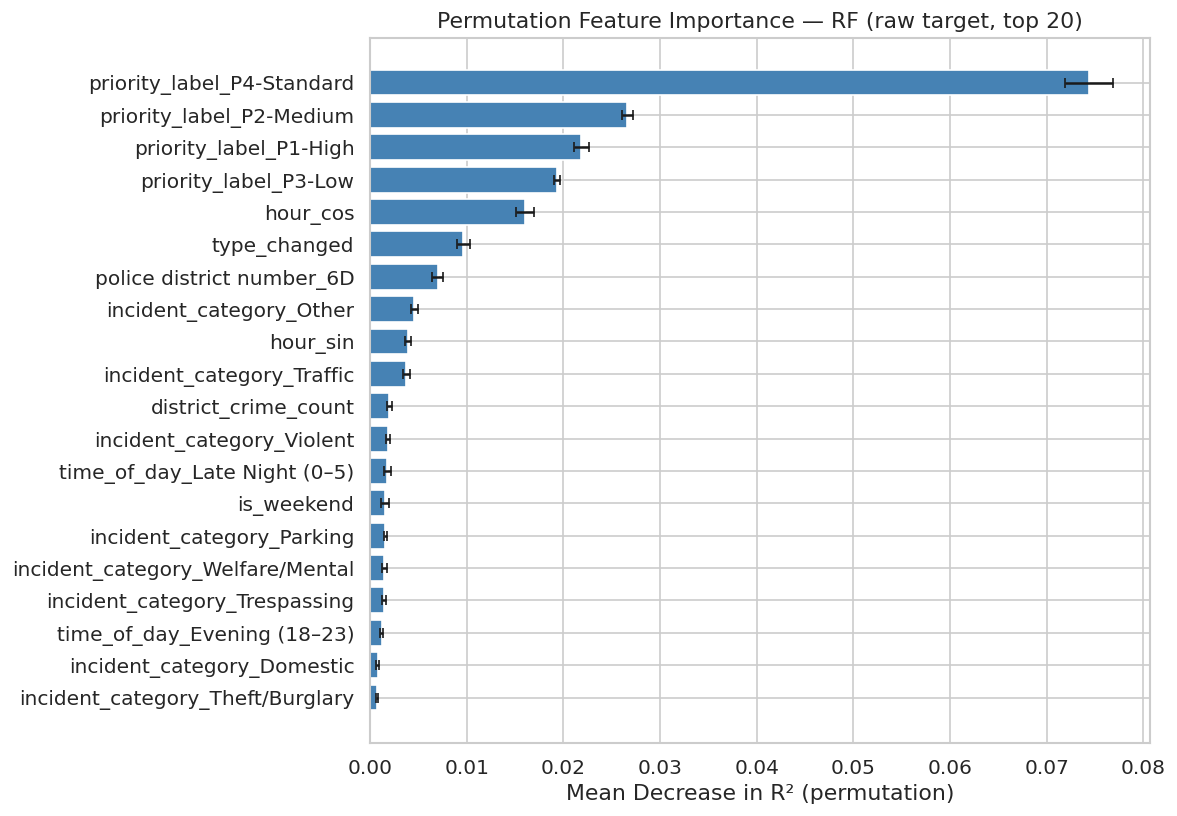

                         Feature  Importance      Std
      priority_label_P4-Standard    0.074385 0.002490
        priority_label_P2-Medium    0.026616 0.000567
          priority_label_P1-High    0.021842 0.000791
           priority_label_P3-Low    0.019341 0.000345
                        hour_cos    0.016048 0.000925
                    type_changed    0.009650 0.000714
       police district number_6D    0.006970 0.000608
         incident_category_Other    0.004562 0.000332
                        hour_sin    0.003899 0.000312
       incident_category_Traffic    0.003742 0.000364
            district_crime_count    0.001993 0.000261
       incident_category_Violent    0.001885 0.000202
    time_of_day_Late Night (0–5)    0.001784 0.000319
                      is_weekend    0.001544 0.000386
       incident_category_Parking    0.001538 0.000150
incident_category_Welfare/Mental    0.001475 0.000211
   incident_category_Trespassing    0.001419 0.000176
     time_of_day_Evening (18

In [55]:
# Permutation importance on test set (more reliable than impurity-based)
print('Computing permutation importance (this may take ~1 min)...')
perm_imp = permutation_importance(
    rf_raw, X_rf_test, y_raw_test,
    n_repeats=10, random_state=SEED, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'  : feature_cols_rf,
    'Importance': perm_imp.importances_mean,
    'Std'      : perm_imp.importances_std
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
perm_sorted = perm_df.sort_values('Importance')
ax.barh(perm_sorted['Feature'], perm_sorted['Importance'],
        xerr=perm_sorted['Std'], color='steelblue', edgecolor='white', capsize=3)
ax.set_xlabel('Mean Decrease in R² (permutation)')
ax.set_title('Permutation Feature Importance — RF (raw target, top 20)')
plt.tight_layout()
plt.savefig('fig_rf_permutation_importance.png', bbox_inches='tight')
plt.show()

print(perm_df.to_string(index=False))

---
## 5. Model Comparison

### 5.1 Performance Summary Table

In [56]:
comparison = pd.DataFrame([
    {
        'Model'         : 'OLS',
        'Target'        : 'Raw (minutes)',
        'R²'            : round(r2_ols_raw,  4),
        'MAE (min)'     : round(mae_ols_raw,  3),
        'RMSE (min)'    : round(rmse_ols_raw, 3)
    },
    {
        'Model'         : 'OLS',
        'Target'        : 'Log (back-transformed)',
        'R²'            : round(r2_ols_log,  4),
        'MAE (min)'     : round(mae_ols_log,  3),
        'RMSE (min)'    : round(rmse_ols_log, 3)
    },
    {
        'Model'         : 'Random Forest',
        'Target'        : 'Raw (minutes)',
        'R²'            : round(r2_rf_raw,  4),
        'MAE (min)'     : round(mae_rf_raw,  3),
        'RMSE (min)'    : round(rmse_rf_raw, 3)
    },
    {
        'Model'         : 'Random Forest',
        'Target'        : 'Log (back-transformed)',
        'R²'            : round(r2_rf_log,  4),
        'MAE (min)'     : round(mae_rf_log,  3),
        'RMSE (min)'    : round(rmse_rf_log, 3)
    },
])

print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

        Model                 Target     R²  MAE (min)  RMSE (min)
          OLS          Raw (minutes) 0.0765      7.400      11.789
          OLS Log (back-transformed) 0.1113      6.840      12.287
Random Forest          Raw (minutes) 0.0919      7.301      11.690
Random Forest Log (back-transformed) 0.1239      6.796      12.264


### 5.2 Predicted vs Actual — All Four Models Side by Side

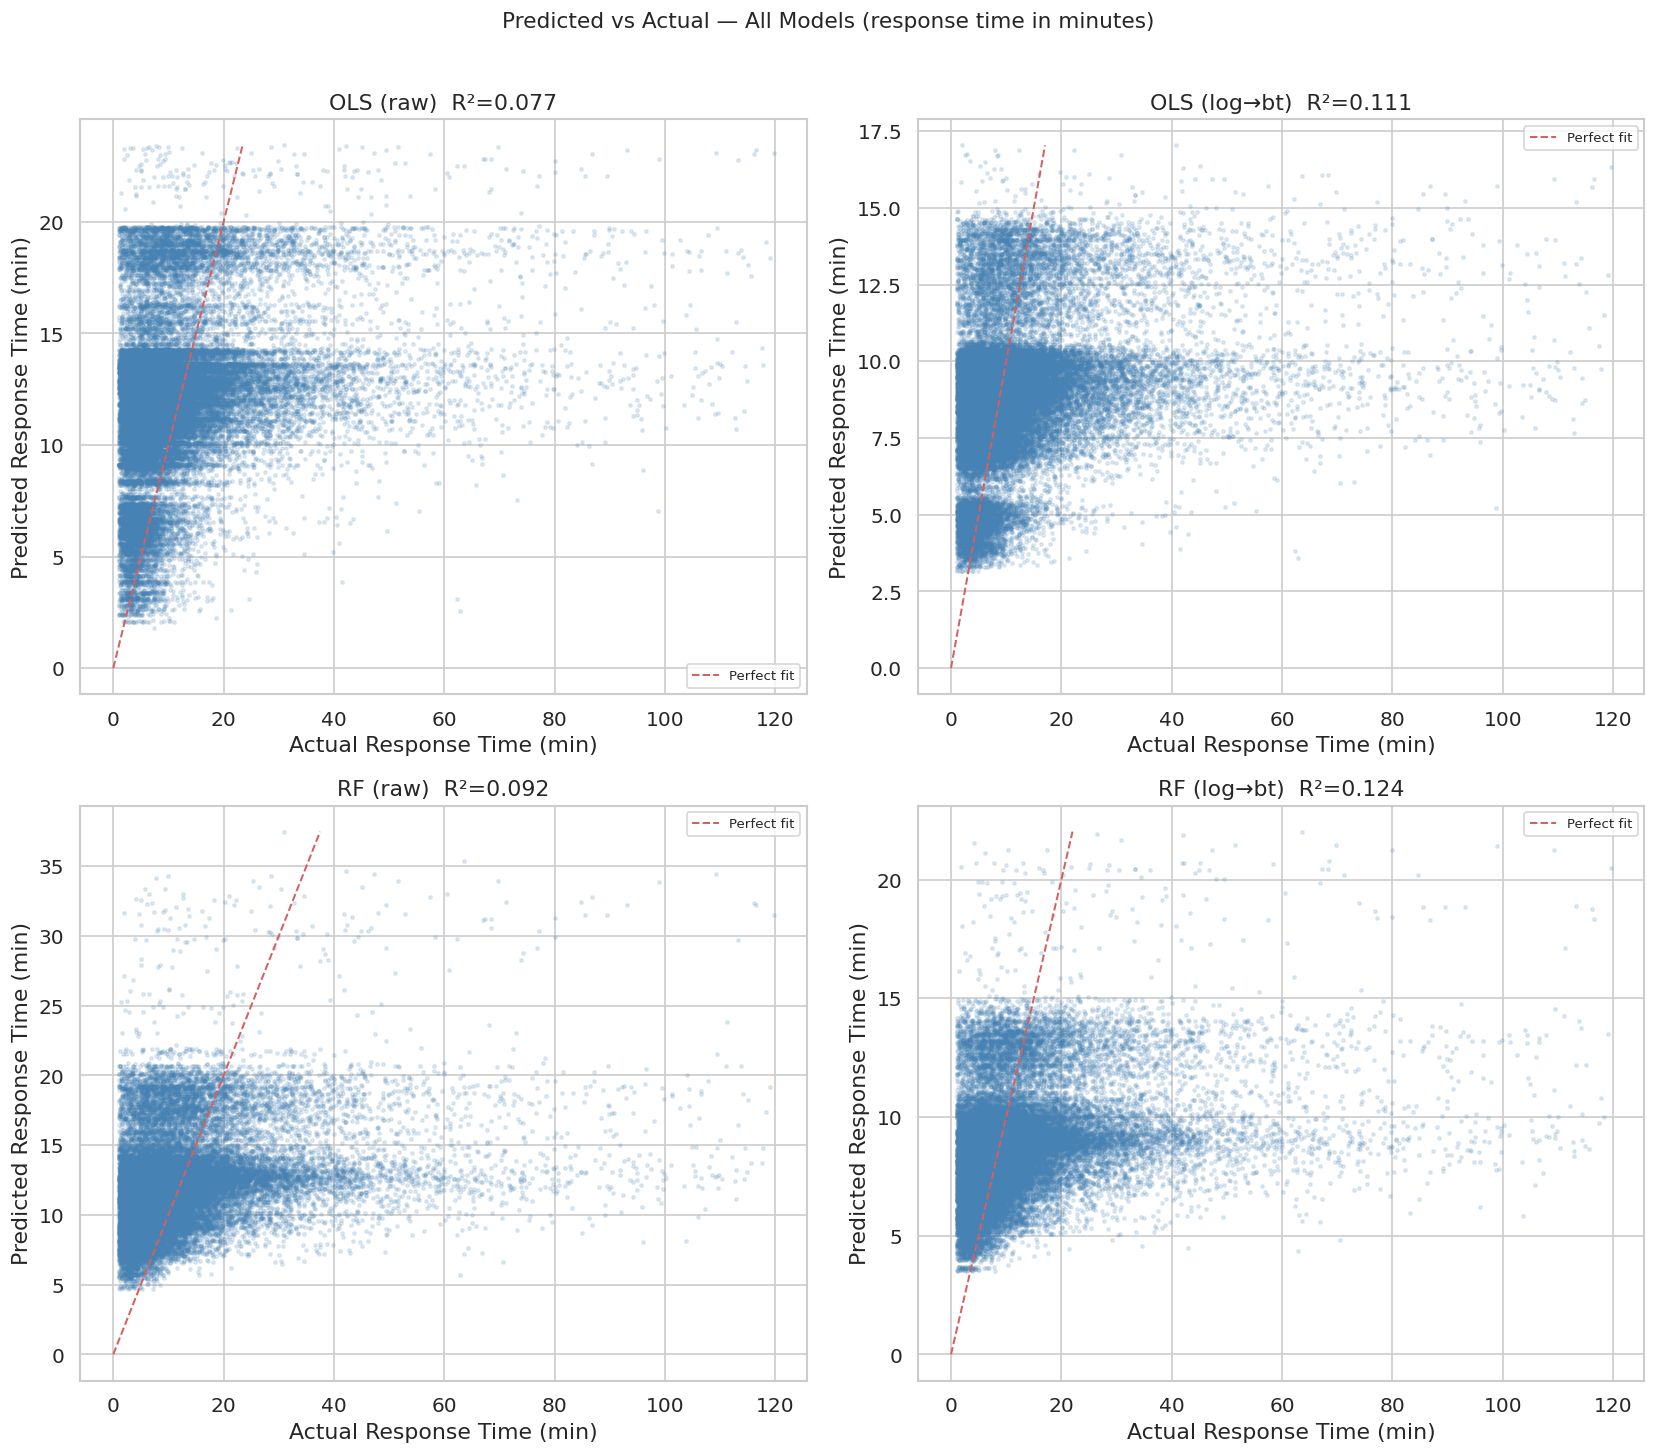

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

configs = [
    (axes[0,0], y_raw_test, y_raw_pred_ols,    f'OLS (raw)  R²={r2_ols_raw:.3f}'),
    (axes[0,1], y_raw_test, y_log_pred_ols_bt, f'OLS (log→bt)  R²={r2_ols_log:.3f}'),
    (axes[1,0], y_raw_test, y_raw_pred_rf,     f'RF (raw)  R²={r2_rf_raw:.3f}'),
    (axes[1,1], y_raw_test, y_log_pred_rf_bt,  f'RF (log→bt)  R²={r2_rf_log:.3f}'),
]

for ax, y_true, y_pred, title in configs:
    ax.scatter(y_true, y_pred, alpha=0.15, s=4, color='steelblue')
    lims = [0, min(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
    ax.set_xlabel('Actual Response Time (min)')
    ax.set_ylabel('Predicted Response Time (min)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — All Models (response time in minutes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_model_comparison_scatter.png', bbox_inches='tight')
plt.show()

### 5.3 Feature Importance Comparison — OLS vs RF

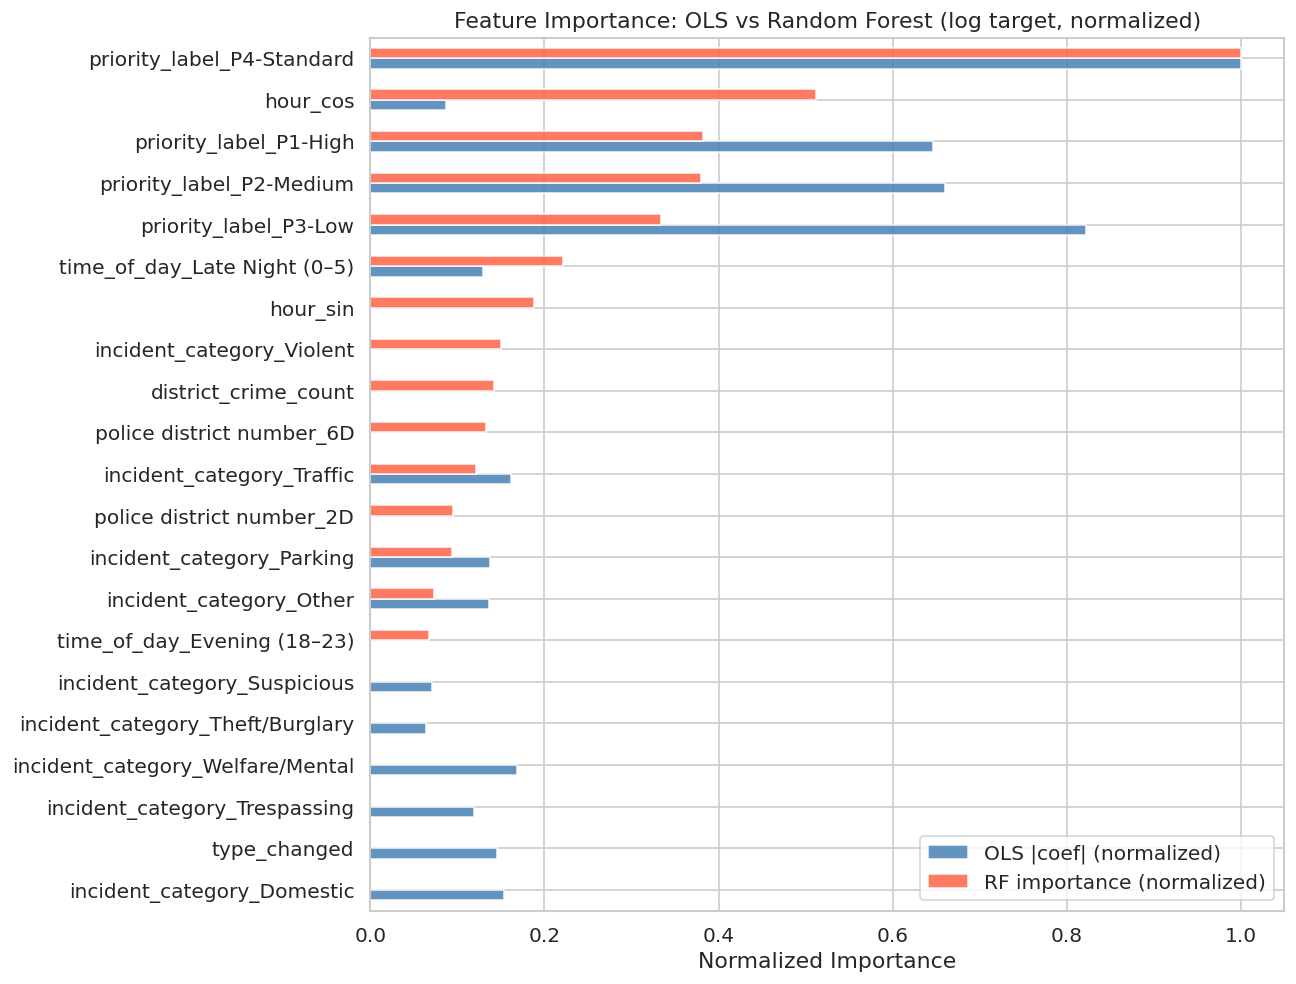

In [60]:
ols_coefs = pd.Series(
    np.abs(ols_log.params[1:]),
    index=feature_cols_ols
).nlargest(15)

rf_imp = pd.Series(
    rf_log.feature_importances_,
    index=feature_cols_rf
).nlargest(15)

# Normalize to 0–1 for side-by-side comparison
ols_norm = ols_coefs / ols_coefs.max()
rf_norm  = rf_imp   / rf_imp.max()

# Union of top features
top_features = list(set(ols_norm.index) | set(rf_norm.index))
compare_df = pd.DataFrame({
    'OLS |coef| (normalized)': ols_norm.reindex(top_features).fillna(0),
    'RF importance (normalized)': rf_norm.reindex(top_features).fillna(0)
}).sort_values('RF importance (normalized)', ascending=True)

fig, ax = plt.subplots(figsize=(11, max(6, len(compare_df)*0.4)))
compare_df.plot(kind='barh', ax=ax,
                color=['steelblue','tomato'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance: OLS vs Random Forest (log target, normalized)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_ols_vs_rf_importance.png', bbox_inches='tight')
plt.show()

---
## 6. Model Interpretation

### OLS Results

**Raw target (R²=0.077, MAE=7.40 min):** The model explains 7.7% of variance in
response time on the raw scale. The MAE of 7.4 minutes means predictions are off
by nearly the median response time itself, reflecting the high inherent variability
in dispatch operations. Residual diagnostics confirm OLS assumption violations on
the raw scale — the fan-shaped residuals vs fitted plot indicates heteroscedasticity,
and the Q-Q plot shows heavy right-tail deviation, both expected given the skewed
distribution of response times.

**Log target (R²=0.111, MAE=6.84 min back-transformed):** The log transformation
improves R² by 45% relative to the raw model and reduces MAE by 0.56 minutes.
The condition number (1.46e+05) is elevated but all VIFs are below 10, indicating
no severe multicollinearity. This is the preferred OLS specification.

**Multicollinearity:** All VIFs are below 10 after removing district dummies from
the OLS model. `district_crime_count` has a VIF of 1.006 — no collinearity concern.

**Significant coefficients (log target):**
- **Priority dominates.** P4-Standard adds 0.989 log-units relative to P0-Emergency,
  corresponding to e^0.989 ≈ 2.7× longer response time. The monotonic increase from
  P1 (0.639) through P4 (0.989) is clean and consistent with operational expectations.
- **District crime count** is significant (p<0.001) with a small negative coefficient
  (-1.58e-05), meaning higher-crime districts have marginally faster response times —
  likely reflecting heavier officer deployment in those areas.
- **Trespassing** is the only incident category with a negative coefficient (-0.117),
  confirming the EDA and statistical test finding of faster-than-average response.
- **Violent incidents** are not significant (p=0.117) after controlling for priority,
  suggesting that when priority is held constant, violent calls don't receive
  meaningfully faster response than the reference category.
- **Late Night** reduces response time by 0.128 log-units (~12% faster), consistent
  with lower overnight call volume. Evening and Morning are not significant.
- **Type changed** adds 0.144 log-units (~15% longer response time), consistent
  with Test 4 findings.
- **Weekend** reduces response time by 0.045 log-units (~4.4% faster), statistically
  significant but practically negligible — consistent with Test 3.

---

### Random Forest Results

**Raw target (R²=0.092, MAE=7.30 min):** RF modestly outperforms OLS on the raw
target. **Log target (R²=0.124, MAE=6.80 min):** RF on the log target is the best
performing model overall, with the lowest MAE across all four specifications.

**Permutation feature importance:** Priority level accounts for the four largest
importance scores by a substantial margin — P4-Standard alone (0.074) is nearly
3× more important than any other feature. `hour_cos` (0.016) and `type_changed`
(0.010) are the next most important, followed by district 6D (0.007) and incident
category features. This confirms the OLS finding that priority is the dominant
structural predictor.

**Agreement between models:** Both OLS and RF rank priority as the top predictor
by a wide margin. The feature importance comparison chart shows strong agreement on
the top features, with RF additionally capturing non-linear contributions from
`hour_cos` and district effects that OLS partially misses.

---

### Overall Assessment

| Model | Target | R² | MAE | RMSE |
|---|---|---|---|---|
| OLS | Raw | 0.077 | 7.40 min | 11.79 min |
| OLS | Log | 0.111 | 6.84 min | 12.29 min |
| Random Forest | Raw | 0.092 | 7.30 min | 11.69 min |
| **Random Forest** | **Log** | **0.124** | **6.80 min** | **12.26 min** |

**The Random Forest on the log target is the best performing model** (R²=0.124,
MAE=6.80 min). The log-target OLS is preferred when interpretability is the
priority, as coefficients translate directly to percentage changes in response time.

The modest R² values across all models are expected and should not be interpreted
as model failure. Dispatch response time has high inherent variability driven by
unobserved real-time factors — officer proximity at time of call, concurrent call
volume, and live traffic conditions — none of which are captured in this dataset.
The models successfully identify the structural predictors (priority, time of day,
incident type, district) while acknowledging that real-time operational factors
account for the majority of remaining variance.

---
## 7. Modeling Summary

### Analytic Decisions
- **Train/test split:** 80/20, random seed=42
- **Outlier exclusion:** Response times >120 min and <1 min excluded in ingestion
- **Missing values:** Rows with NA in any feature or target dropped before modeling
- **Categorical encoding:** One-hot encoding with `drop_first=True` to avoid dummy variable trap
- **Hour encoding:** Cyclic (sin/cos) to preserve continuity between hour 23 and hour 0
- **RF hyperparameters:** n_estimators=200, max_depth=12, min_samples_leaf=20 (prevents overfitting on large N)

### Limitations
- R² values for response time prediction are expected to be modest — dispatch response time has high inherent variability driven by unobserved factors (officer location, traffic, concurrent call volume)
- OLS assumes linearity and homoscedasticity; residual plots should be inspected to assess violations
- Random Forest feature importances (impurity-based) can be biased toward high-cardinality features; permutation importance is a more reliable alternative
- District-level crime density is a weak proxy for local workload; beat or PRA-level aggregates would be stronger if sample sizes allow

### Next Steps (if extending)
- Gradient Boosting (XGBoost/LightGBM) for potentially stronger RF alternative
- Interaction terms in OLS (priority × time_of_day)
- Spatial modeling if geographic coordinates are used directly
- Dashboard visualizing predicted vs actual response times by district